In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/drive/MyDrive/MBCA/1차 팀 프로젝트/데이터 파일/부산_관광체류강도_전체(in).csv")

# 기준연월을 날짜형으로 변환
df['기준연월'] = pd.to_datetime(df['기준연월'].astype(str), format='%Y%m')

# 필요 없는 빈 컬럼 제거
df = df.dropna(axis=1, how='all')

df.head()

,기준연월,시·도코드,시·도명,시·군·구 코드,시·군·구 명,체류강도_지표코드,체류특성,체류특성_강도지수
0,2025-01-01,26,부산광역시,26110,중구,2101,타권역 방문자 비중,115.68
1,2025-01-01,26,부산광역시,26110,중구,2102,숙박 비중,56.27
2,2025-01-01,26,부산광역시,26110,중구,2103,1박 방문자수,67.64
3,2025-01-01,26,부산광역시,26110,중구,2104,2박 방문자수,67.30
4,2025-01-01,26,부산광역시,26110,중구,2105,3박 방문자수,67.94


In [6]:
# 한글 폰트 설치
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

# matplotlib 전체에 한글 폰트 적용
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

print("적용된 폰트:", font_name)

Selecting previously unselected package fonts-nanum.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
적용된 폰트: NanumGothic


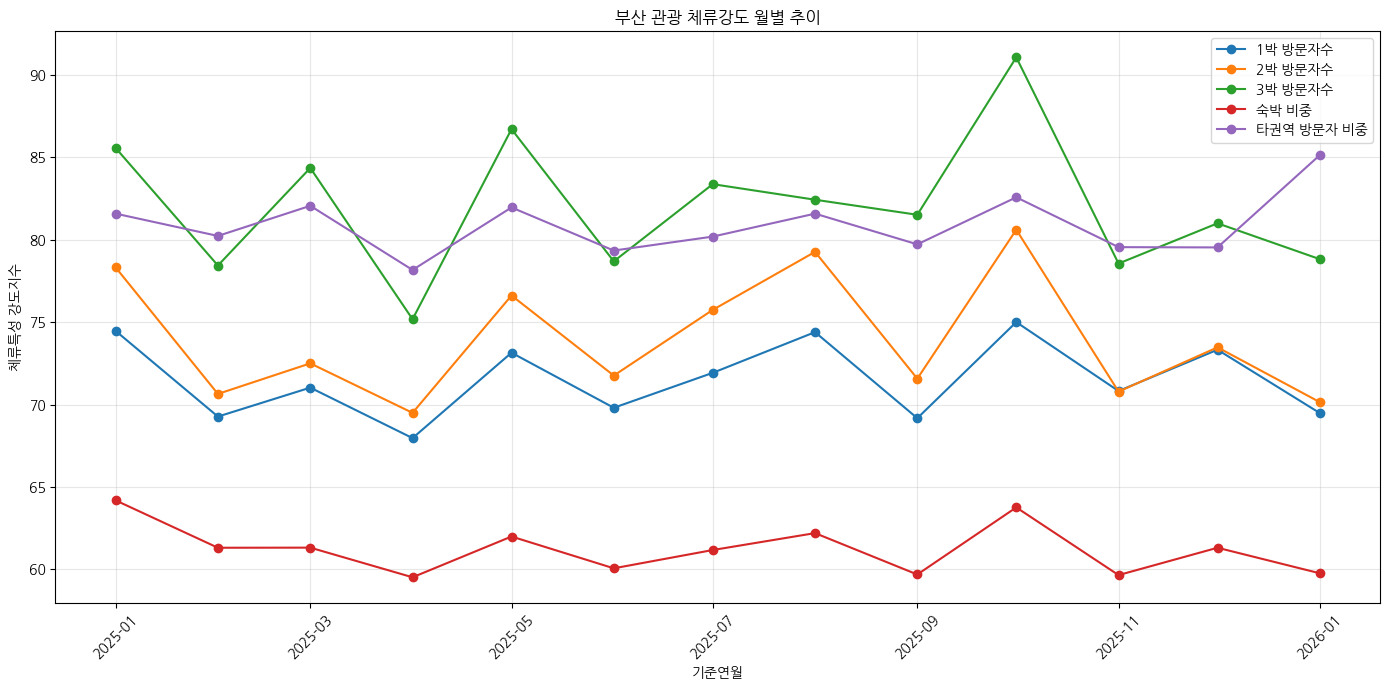

In [7]:
monthly = (
    df.groupby(['기준연월', '체류특성'])['체류특성_강도지수']
      .mean()
      .reset_index()
)

pivot = monthly.pivot(
    index='기준연월',
    columns='체류특성',
    values='체류특성_강도지수'
)

plt.figure(figsize=(14, 7))

for column in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[column],
        marker='o',
        label=column
    )

plt.title('부산 관광 체류강도 월별 추이')
plt.xlabel('기준연월')
plt.ylabel('체류특성 강도지수')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

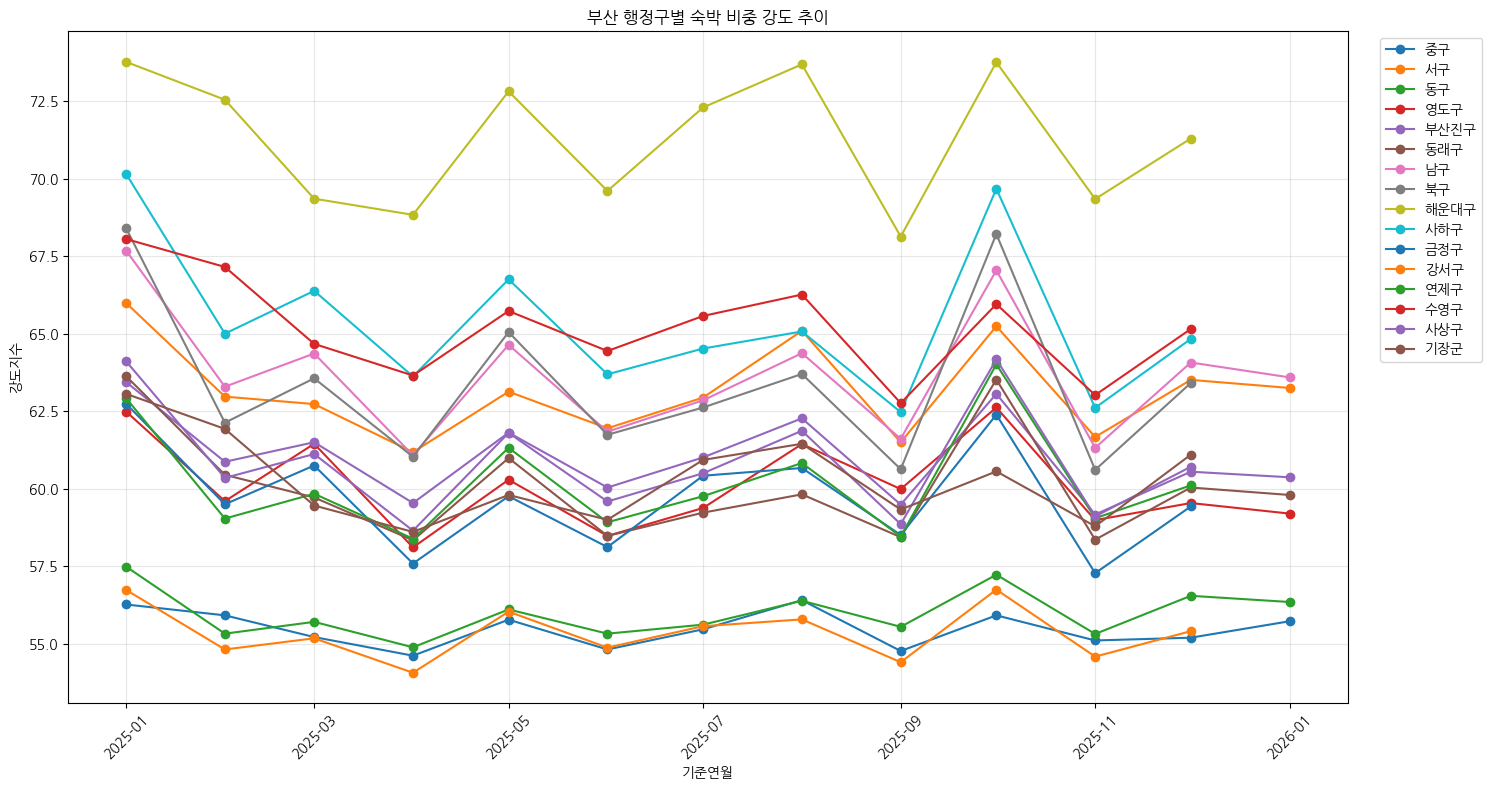

In [8]:
target = '숙박 비중'

temp = df[df['체류특성'] == target]

plt.figure(figsize=(15, 8))

for gu in temp['시·군·구 명'].unique():

    gu_data = temp[temp['시·군·구 명'] == gu]

    plt.plot(
        gu_data['기준연월'],
        gu_data['체류특성_강도지수'],
        marker='o',
        label=gu
    )

plt.title(f'부산 행정구별 {target} 강도 추이')
plt.xlabel('기준연월')
plt.ylabel('강도지수')
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

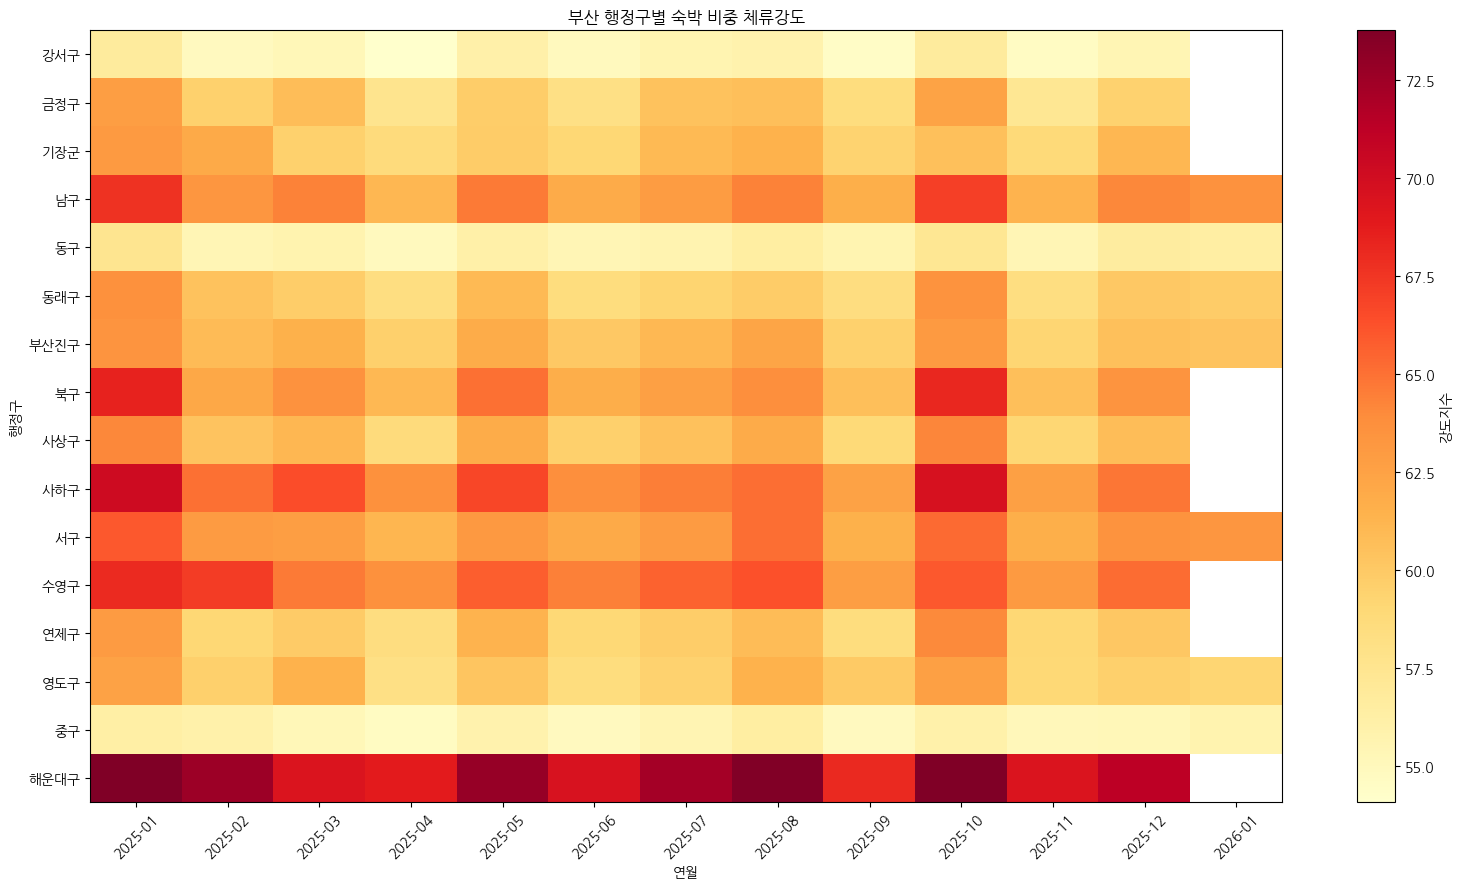

In [9]:
target = '숙박 비중'

temp = df[df['체류특성'] == target].copy()

heatmap_data = temp.pivot_table(
    index='시·군·구 명',
    columns='기준연월',
    values='체류특성_강도지수',
    aggfunc='mean'
)

plt.figure(figsize=(16, 9))

plt.imshow(
    heatmap_data,
    aspect='auto',
    cmap='YlOrRd'
)

plt.colorbar(label='강도지수')

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xticks(
    range(len(heatmap_data.columns)),
    [x.strftime('%Y-%m') for x in heatmap_data.columns],
    rotation=45
)

plt.title(f'부산 행정구별 {target} 체류강도')
plt.xlabel('연월')
plt.ylabel('행정구')

plt.tight_layout()
plt.show()

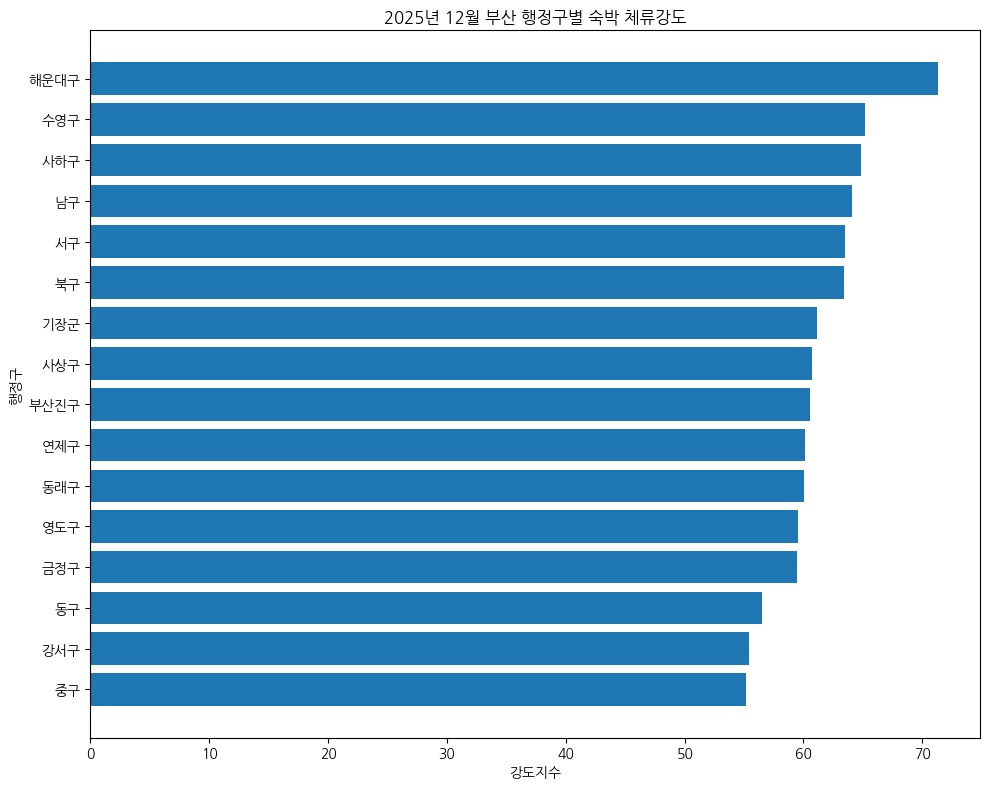

In [16]:
target = '숙박 비중'
target_month = pd.Timestamp('2025-12-01')

temp = df[
    (df['체류특성'] == target) &
    (df['기준연월'] == target_month)
].copy()

temp = temp.sort_values(
    '체류특성_강도지수',
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    temp['시·군·구 명'],
    temp['체류특성_강도지수']
)

plt.title('2025년 12월 부산 행정구별 숙박 체류강도')
plt.xlabel('강도지수')
plt.ylabel('행정구')

plt.tight_layout()
plt.show()